In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("retail_sales_data.csv")

print("Original Dataset")
print(df.head())

Original Dataset
     Store        Date     Product  Units_Sold  Unit_Price  Discount_Percent  \
0  Store_C  2026-01-01      Laptop        27.0        80.0              15.0   
1  Store_C  2026-01-02      Tablet        22.0       250.0               0.0   
2  Store_A  2026-01-03      Tablet        12.0       250.0               5.0   
3  Store_C  2026-01-04  Headphones        29.0        80.0              10.0   
4  Store_A  2026-01-05  Headphones        13.0       500.0               5.0   

    Sales   Profit  
0  1836.0   329.19  
1  5500.0  1047.61  
2  2850.0   268.91  
3  2088.0   314.63  
4  6175.0   537.68  


In [3]:
print("\nMissing Values")
print(df.isnull().sum())

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col].fillna(df[col].mean(), inplace=True)

print("\nDataset After Removing Missing Values")
print(df.head())


Missing Values
Store               0
Date                0
Product             0
Units_Sold          0
Unit_Price          0
Discount_Percent    0
Sales               1
Profit              0
dtype: int64

Dataset After Removing Missing Values
     Store        Date     Product  Units_Sold  Unit_Price  Discount_Percent  \
0  Store_C  2026-01-01      Laptop        27.0        80.0              15.0   
1  Store_C  2026-01-02      Tablet        22.0       250.0               0.0   
2  Store_A  2026-01-03      Tablet        12.0       250.0               5.0   
3  Store_C  2026-01-04  Headphones        29.0        80.0              10.0   
4  Store_A  2026-01-05  Headphones        13.0       500.0               5.0   

    Sales   Profit  
0  1836.0   329.19  
1  5500.0  1047.61  
2  2850.0   268.91  
3  2088.0   314.63  
4  6175.0   537.68  


C:\Users\kshit\AppData\Local\Temp\ipykernel_5568\778741074.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mean(), inplace=True)


In [4]:
print("\nCorrelation Matrix")
print(df[numeric_columns].corr())


Correlation Matrix
                  Units_Sold  Unit_Price  Discount_Percent     Sales    Profit
Units_Sold          1.000000    0.180755         -0.021901  0.253976  0.211940
Unit_Price          0.180755    1.000000         -0.134896  0.901073  0.890363
Discount_Percent   -0.021901   -0.134896          1.000000 -0.143048 -0.133009
Sales               0.253976    0.901073         -0.143048  1.000000  0.952821
Profit              0.211940    0.890363         -0.133009  0.952821  1.000000


In [5]:
normalized_df = df.copy()

for col in numeric_columns:
    minimum = df[col].min()
    maximum = df[col].max()
    normalized_df[col] = (df[col] - minimum) / (maximum - minimum)

print("\nNormalized Data")
print(normalized_df.head())


Normalized Data
     Store        Date     Product  Units_Sold  Unit_Price  Discount_Percent  \
0  Store_C  2026-01-01      Laptop    0.083893    0.070968          1.000000   
1  Store_C  2026-01-02      Tablet    0.067114    0.290323          0.000000   
2  Store_A  2026-01-03      Tablet    0.033557    0.290323          0.333333   
3  Store_C  2026-01-04  Headphones    0.090604    0.070968          0.666667   
4  Store_A  2026-01-05  Headphones    0.036913    0.612903          0.333333   

      Sales    Profit  
0  0.082614  0.092022  
1  0.255485  0.300178  
2  0.130455  0.074556  
3  0.094503  0.087803  
4  0.287332  0.152430  


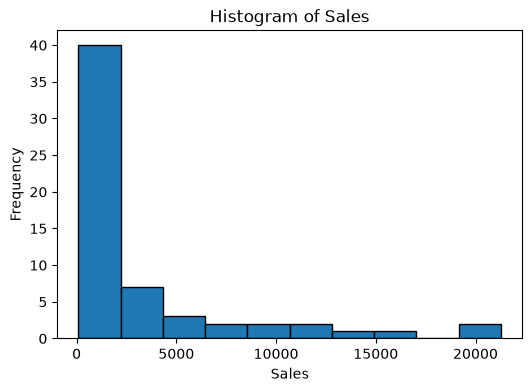

In [6]:
if "Sales" in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df["Sales"], bins=10, edgecolor="black")
    plt.title("Histogram of Sales")
    plt.xlabel("Sales")
    plt.ylabel("Frequency")
    plt.show()

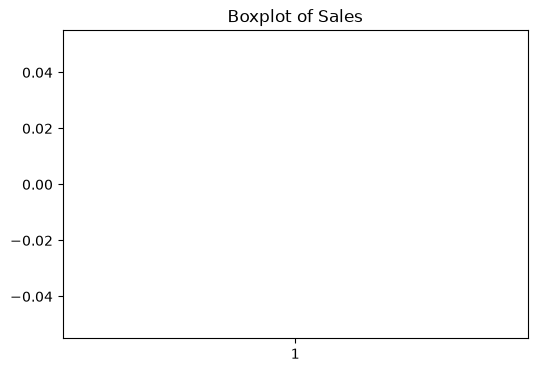

In [ ]:

if "Sales" in df.columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df["Sales"])
    plt.title("Boxplot of Sales")
    plt.show()

In [8]:
if "Sales" in df.columns:
    Q1 = df["Sales"].quantile(0.25)
    Q3 = df["Sales"].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    cleaned_df = df[(df["Sales"] >= lower) & (df["Sales"] <= upper)]

    print("\nOriginal Rows :", len(df))
    print("Rows After Removing Outliers :", len(cleaned_df))


Original Rows : 61
Rows After Removing Outliers : 51


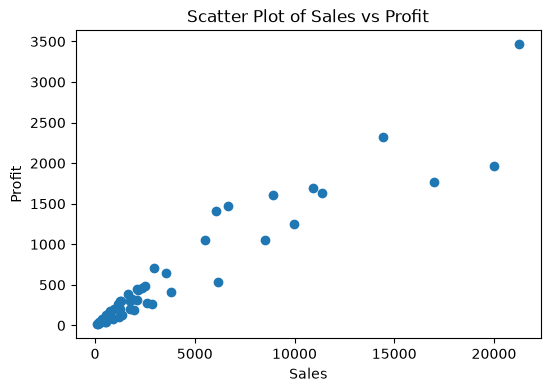

In [9]:
if "Sales" in df.columns and "Profit" in df.columns:
    plt.figure(figsize=(6,4))
    plt.scatter(df["Sales"], df["Profit"])
    plt.title("Scatter Plot of Sales vs Profit")
    plt.xlabel("Sales")
    plt.ylabel("Profit")
    plt.show()